# New Section

In [ ]:
!pip install -q kaggle

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'Alsafaalwahshi'
os.environ['KAGGLE_KEY'] = 'b80bcb53f6c5ff4db5b4a82958a6d916'

In [ ]:
!kaggle datasets download -d KhansaUrooj/malex-200k-balanced-byteplot

Dataset URL: https://www.kaggle.com/datasets/KhansaUrooj/malex-200k-balanced-byteplot
License(s): other
100% 7.42G/7.42G [01:13<00:00, 108MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/

drive  malex-200k-balanced-byteplot.zip  sample_data


In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import time
import random

zip_path = "/content/malex-200k-balanced-byteplot.zip"

extract_path = "/content/malex_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall(extract_path)

print(" Dataset extracted ")

 Dataset extracted 


In [ ]:
print(os.listdir("/content/malex_dataset"))

['malware', 'benign']


In [ ]:
Benign_Dir = "/content/malex_dataset/benign"
Attack_Dir = "/content/malex_dataset/malware"

benign_files = [
    os.path.join(Benign_Dir, f)
    for f in os.listdir(Benign_Dir)
    if f.endswith(".png")
]

attack_files = [
    os.path.join(Attack_Dir, f)
    for f in os.listdir(Attack_Dir)
    if f.endswith(".png")
]
SEED = 42
random.seed(SEED)
benign_files = random.sample(benign_files, 5000)
attack_files = random.sample(attack_files, 5000)


print("Verify Dataset")
print(f"Benign images : {len(benign_files):,}")
print(f"Attack images : {len(attack_files):,}")
print(f"Total number of images  : {len(benign_files)+len(attack_files):,}")
print("Dataset Ready")

Verify Dataset
Benign images : 5,000
Attack images : 5,000
Total number of images  : 10,000
Dataset Ready


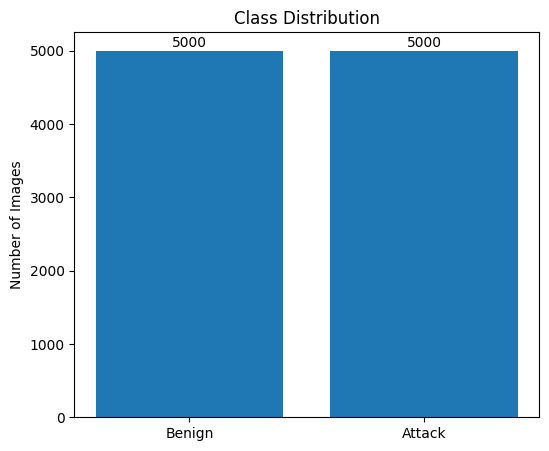

In [ ]:
#EDA
fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(
    ["Benign", "Attack"],
    [len(benign_files), len(attack_files)]
)

ax.set_title("Class Distribution")

ax.set_ylabel("Number of Images")

for bar in bars:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.show()

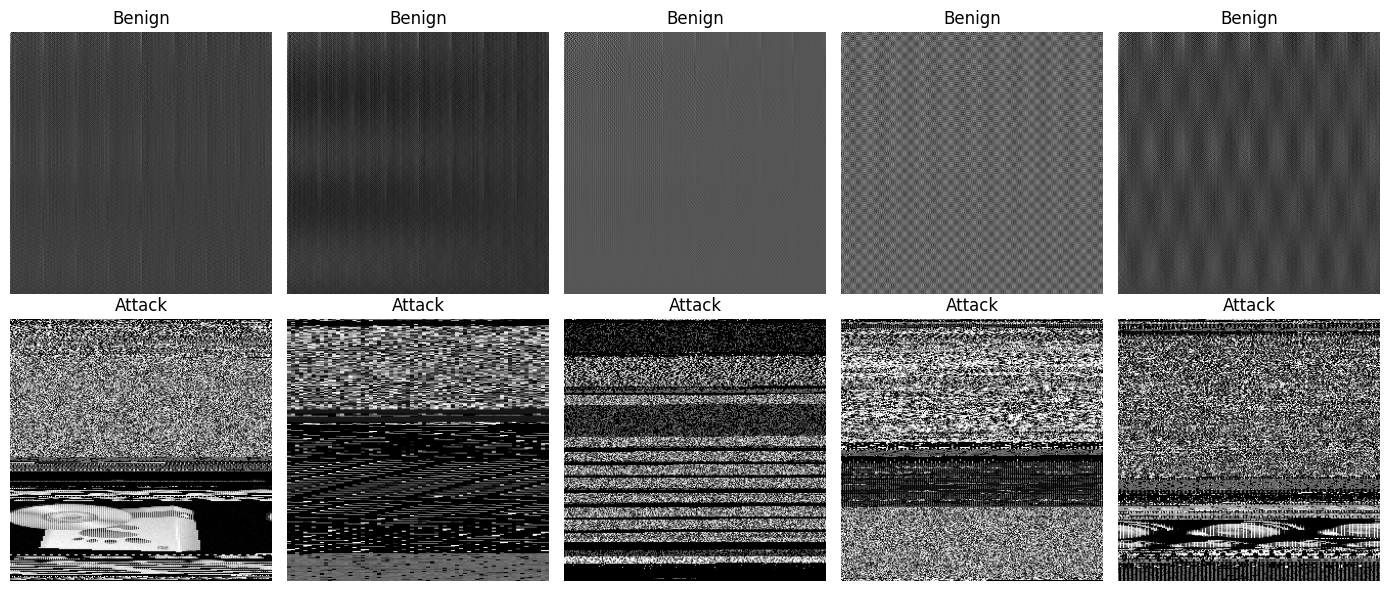

In [ ]:
random.seed(42)
fig, axes = plt.subplots(2, 5, figsize=(14,6))

# Benign
for i, p in enumerate(random.sample(benign_files, 5)):
    axes[0][i].imshow(
        Image.open(p),
        cmap="gray"
    )

    axes[0][i].axis("off")
    axes[0][i].set_title("Benign")

# Attack
for i, p in enumerate(random.sample(attack_files, 5)):
    axes[1][i].imshow(
        Image.open(p),
        cmap="gray"
    )

    axes[1][i].axis("off")
    axes[1][i].set_title("Attack")

plt.tight_layout()
plt.show()

In [ ]:
Benign_Dir = "/content/malex_dataset/benign"
Attack_Dir = "/content/malex_dataset/malware"

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

benign_files = [
    os.path.join(Benign_Dir, f)
    for f in os.listdir(Benign_Dir)
    if f.endswith(".png")
]

ben_files = random.sample(benign_files, 2000)
ben_labels = [0] * len(ben_files)

attack_files = [
    os.path.join(Attack_Dir, f)
    for f in os.listdir(Attack_Dir)
    if f.endswith(".png")
]

attack_files = random.sample(attack_files, 2000)
attack_labels = [1] * len(attack_files)

all_paths = ben_files + attack_files
all_labels = ben_labels + attack_labels


print("Summery")
print(f"Benign Images : {len(ben_files):,}")
print(f"Attack Images : {len(attack_files):,}")
print(f"Total Images  : {len(all_paths):,}")
print(f"Image Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(" Dataset Ready")

Summery
Benign Images : 2,000
Attack Images : 2,000
Total Images  : 4,000
Image Size    : 224x224
Batch Size    : 32
 Dataset Ready


In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("DATA SPLIT")
print(f"Train      : {len(train_paths):,}")
print(f"Validation : {len(val_paths):,}")
print(f"Test       : {len(test_paths):,}")
print(" Data split complete")

DATA SPLIT
Train      : 2,800
Validation : 600
Test       : 600
 Data split complete


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
def process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (224,224)
    )

    img = tf.cast(
        img,
        tf.float32
    ) / 255.0

    return img, label

def build_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        ds = ds.shuffle(
            len(paths),
            seed=SEED
        )
    ds = ds.map(
        process_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(
    train_paths,
    train_labels,
    shuffle=True
)
val_ds = build_dataset(
    val_paths,
    val_labels
)

test_ds = build_dataset(
    test_paths,
    test_labels
)

print(" TensorFlow Datasets Ready")

 TensorFlow Datasets Ready


In [ ]:
for images, labels in train_ds.take(1):
    print("Image Shape :", images.shape)
    print("Labels Shape:", labels.shape)
    print("Pixel Min   :", tf.reduce_min(images).numpy())
    print("Pixel Max   :", tf.reduce_max(images).numpy())
print("Dataset Ready")

Image Shape : (32, 224, 224, 3)
Labels Shape: (32,)
Pixel Min   : 0.0
Pixel Max   : 1.0
Dataset Ready


In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
def build_model():
    inputs = layers.Input(
        shape=(224,224,3)
    )

    base_model = MobileNetV2(
        alpha= 0.35,
        input_shape=(224,224,3),

        include_top=False,

        weights="imagenet"
    )

    base_model.trainable = True
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    return model

model = build_model()
model.summary()

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_224            │ (None, 7, 7, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,305 (2.19 MB)

 Trainable params: 560,225 (2.14 MB)

 Non-trainable params: 14,080 (55.00 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = {
    0: 1.0,
    1: 1.0
}
print("Class weights:", class_weights)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy( name="accuracy"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

print(" Model compiled successfully")

Class weights: {0: 1.0, 1: 1.0}
 Model compiled successfully


In [ ]:
checkpoint_path = "/content/drive/MyDrive/malware_project/best_model.h5"

os.makedirs(
    os.path.dirname(checkpoint_path),
    exist_ok=True
)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks Ready")

Callbacks Ready


In [ ]:
total_params = model.count_params()
print("Summery")
print("Input Shape : 224 x 224 x 3")
print("Output      : Binary Classification")
print(f"Parameters  : {total_params:,}")
print("Architecture: MobileNetV2")

Summery
Input Shape : 224 x 224 x 3
Output      : Binary Classification
Parameters  : 574,305
Architecture: MobileNetV2


In [ ]:
print("Start Training")
print(f"Train Samples : {len(train_paths):,}")
print(f"Validation    : {len(val_paths):,}")
print(f"Batch Size    : {BATCH_SIZE}")

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
total_time = (end_time - start_time) / 60
print(" Training completed")
print(f"Training Time: {total_time:.2f} minutes")

Start Training
Train Samples : 2,800
Validation    : 600
Batch Size    : 32
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9518 - loss: 0.0906 - precision: 0.9460 - recall: 0.9518
Epoch 1: val_accuracy improved from None to 0.75000, saving model to /content/drive/MyDrive/malware_project/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/malware_project/best_model.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 124s 705ms/step - accuracy: 0.9829 - loss: 0.0465 - precision: 0.9822 - recall: 0.9836 - val_accuracy: 0.7500 - val_loss: 1.0462 - val_precision: 1.0000 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 2/5
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 4.8960e-04 - precision: 1.0000 - recall: 0.9999
Epoch 2: val_accuracy improved from 0.75000 to 0.83000, saving model to /content/drive/MyDrive/malware_project/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/malware_project/best_model.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9993 - loss: 0.0019 - precision: 0.9993 - recall: 0.9993 - val_accuracy: 0.8300 - val_loss: 0.7007 - val_precision: 1.0000 - val_recall: 0.6600 - learning_rate: 0.0010
Epoch 3/5
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 5.6627e-04 - precision: 1.0000 - recall: 1.0000
Epoch 3: val_accuracy improved from 0.83000 to 0.92500, saving model to /content/drive/MyDrive/malware_project/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/malware_project/best_model.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 1.0000 - loss: 5.8490e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9250 - val_loss: 0.3316 - val_precision: 1.0000 - val_recall: 0.8500 - learning_rate: 0.0010
Epoch 4/5
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 8.1298e-05 - precision: 1.0000 - recall: 1.0000
Epoch 4: val_accuracy did not improve from 0.92500
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 1.0000 - loss: 4.9964e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8933 - val_loss: 0.5912 - val_precision: 1.0000 - val_recall: 0.7867 - learning_rate: 0.0010
Epoch 5/5
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 5.7588e-05 - precision: 1.0000 - recall: 1.0000
Epoch 5: val_accuracy did not improve from 0.92500
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 1.0000 - loss: 6.3503e-05 - precision: 1.0000 - recall: 

In [ ]:
best_accuracy = max(history.history["val_accuracy"])
best_recall = max(history.history["val_recall"])
best_precision = max(history.history["val_precision"])
best_epoch = (
    history.history["val_accuracy"].index(best_accuracy) + 1
)

print(" Training Result")
print(f"Best Epoch     : {best_epoch}")
print(f"Best Accuracy  : {best_accuracy * 100:.2f}%")
print(f"Best Recall    : {best_recall * 100:.2f}%")
print(f"Best Precision : {best_precision * 100:.2f}%")
print("Training Complete")

 Training Result
Best Epoch     : 3
Best Accuracy  : 92.50%
Best Recall    : 85.00%
Best Precision : 100.00%
Training Complete


In [ ]:
print("Evaluation results:")

results = model.evaluate(test_ds, verbose=1)
print("\nTest Results:")
print(f"Accuracy  : {results[1]:.4f}")
print(f"Recall    : {results[2]:.4f}")
print(f"Precision : {results[3]:.4f}")

Evaluation results:
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9100 - loss: 0.4207 - precision: 1.0000 - recall: 0.8200

Test Results:
Accuracy  : 0.9100
Recall    : 0.8200
Precision : 1.0000


In [ ]:
import numpy as np

print("Getting Predictions")

y_pred_probs = model.predict(test_ds)

y_pred = (
    y_pred_probs > 0.5
).astype(int).flatten()

y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_true.shape)

Getting Predictions
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 328ms/step
Predictions shape: (600,)
True labels shape: (600,)


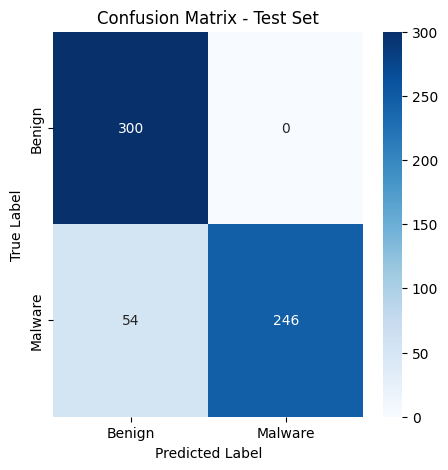

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malware"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.85      1.00      0.92       300
     Malware       1.00      0.82      0.90       300

    accuracy                           0.91       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.91      0.91       600



In [ ]:
save_path = "/content/drive/MyDrive/malware_project/ids_image.h5"

os.makedirs(
    os.path.dirname(save_path),
    exist_ok=True
)

model.save(save_path)

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()
with open('ids_model_quant.tflite', 'wb') as f:
    f.write(tflite_quant_model)



Saved artifact at '/tmp/tmpdgb9v1sl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139477063547216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238384016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477063547024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477063548176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477063547408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238384400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238385168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238384784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477238382864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13947723838555

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/malware_project/ids_image.tflite"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>